<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/TimeA014.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TimeA014: Bifurcation Lens at Bias = 0.01
Profile     | Feedback | Entropy Slope | Memory Retention | Irreversibility Index | Resonance Amplitude
flat         |     0.00 |        0.16532 |           0.99804 |              62.38149 |              0.25007
flat         |     0.05 |       -0.28759 |           0.93402 |             160.65044 |              0.28940
flat         |     0.10 |       -0.28877 |           0.93367 |             162.19068 |              0.28749
flat         |     0.15 |       -0.28974 |           0.93436 |             160.37763 |              0.28689
flat         |     0.20 |       -0.28744 |           0.93350 |             161.60664 |              0.28827
flat         |     0.25 |       -0.29040 |           0.93409 |             161.77728 |              0.28720
flat         |     0.30 |       -0.28849 |           0.93419 |             160.85286 |              0.28931
flat         |     0.35 |       -0.29042 |           0.93407 |             162.08210 |            

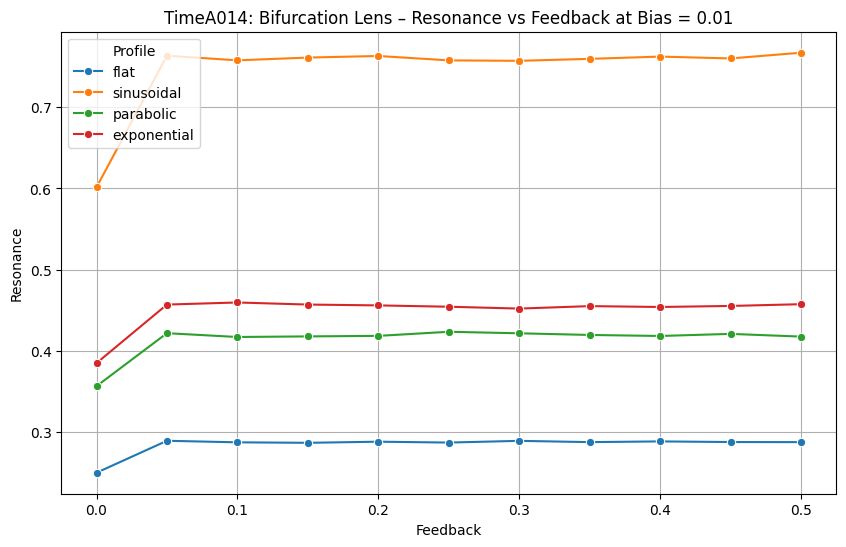

In [1]:
# 🔍 TimeA014: The Bifurcation Lens
# Zooming into feedback bifurcation across curvature profiles at bias = 0.01
# Author: Chris & Copilot | Arc VI: Resonant Thresholds | ACT031
# Reproducibility Tag: TimeA014_v1

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- Parameters ---
N = 100
T = 150
bias_strength = 0.01
xi_locking = True
feedback_range = np.linspace(0.0, 0.5, 11)
curvature_profiles = ['flat', 'sinusoidal', 'parabolic', 'exponential']
seed = 42
np.random.seed(seed)

# --- Curvature Profiles ---
def curvature_profile(profile, N):
    x = np.linspace(-1, 1, N)
    if profile == 'flat':
        return np.zeros((N, N))
    elif profile == 'sinusoidal':
        return np.sin(np.pi * x)[:, None]
    elif profile == 'parabolic':
        return -(x**2)[:, None]
    elif profile == 'exponential':
        return -np.exp(-5 * x**2)[:, None]
    else:
        raise ValueError("Unknown profile")

# --- Initialization ---
def initialize_lattice(N, profile):
    base = np.random.rand(N, N)
    curvature = curvature_profile(profile, N)
    return base + curvature

# --- Entropy Calculation ---
def compute_entropy(lattice):
    hist, _ = np.histogram(lattice, bins=50, density=True)
    hist = hist[hist > 0]
    return -np.sum(hist * np.log(hist))

# --- Evolution Function ---
def evolve_lattice(lattice, xi_locking, bias_strength, feedback_strength, past_entropy):
    entropy_map = np.gradient(lattice)[0]
    feedback_scalar = feedback_strength * (np.mean(past_entropy) if len(past_entropy) > 0 else 0)
    feedback_field = np.full_like(lattice, feedback_scalar)
    lattice += 0.01 * np.random.randn(*lattice.shape) + bias_strength * entropy_map + feedback_field
    if xi_locking:
        lattice = np.clip(lattice, 0.2, 0.8)
    return lattice

# --- Simulation Loop ---
def run_simulation(N, T, profile, feedback_strength):
    lattice = initialize_lattice(N, profile)
    entropy_series = []
    cumulative_drift = np.zeros_like(lattice)
    for t in range(T):
        prev_lattice = lattice.copy()
        past_entropy = np.array(entropy_series[-10:]) if len(entropy_series) >= 10 else np.zeros(10)
        lattice = evolve_lattice(lattice, xi_locking, bias_strength, feedback_strength, past_entropy)
        cumulative_drift += lattice - prev_lattice
        S = compute_entropy(lattice)
        entropy_series.append(S)
    return np.array(entropy_series), cumulative_drift

# --- Metrics ---
def compute_metrics(entropy_series, cumulative_drift):
    slope = np.polyfit(np.arange(len(entropy_series)), entropy_series, 1)[0]
    memory = np.corrcoef(entropy_series[:-1], entropy_series[1:])[0,1]
    irreversibility_index = np.sum(np.abs(np.diff(entropy_series)))
    resonance_amplitude = np.std(cumulative_drift)
    return slope, memory, irreversibility_index, resonance_amplitude

# --- Run Scan ---
results = []
for profile in curvature_profiles:
    for feedback in feedback_range:
        entropy_series, drift = run_simulation(N, T, profile, feedback)
        metrics = compute_metrics(entropy_series, drift)
        results.append((profile, feedback) + metrics)

# --- Output ---
print("TimeA014: Bifurcation Lens at Bias = 0.01")
print("Profile     | Feedback | Entropy Slope | Memory Retention | Irreversibility Index | Resonance Amplitude")
for r in results:
    print(f"{r[0]:<12} | {r[1]:>8.2f} | {r[2]:>14.5f} | {r[3]:>17.5f} | {r[4]:>21.5f} | {r[5]:>20.5f}")

# --- Plotting ---
df = pd.DataFrame(results, columns=['Profile', 'Feedback', 'EntropySlope', 'Memory', 'Irreversibility', 'Resonance'])
plt.figure(figsize=(10,6))
sns.lineplot(data=df, x='Feedback', y='Resonance', hue='Profile', marker='o')
plt.title('TimeA014: Bifurcation Lens – Resonance vs Feedback at Bias = 0.01')
plt.grid(True)
plt.show()
